In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
plt.rcParams['font.family'] = 'Times New Roman'
ENG_result_mean = [0.5268587470054626, 0.6050552427768707, 0.545380711555481, 0.7593218088150024, 0.4755933475494385, 0.5478944170475006, 0.5720518922805786, 0.5684217519760132, 0.6220743030309677, 0.7251902371163402]

EMG_result_mean = [0.42878782749176025, 0.3310706913471222, 0.35904206335544586, 0.6106011271476746, 0.5019441395998001, 0.6005978584289551,
                   0.5293917655944824, 0.5303820222616196, 0.6454729735851288, 0.639594031062847]

ENG_result_std = [0.01738905906677246, 0.008295983076095581, 0.007301270961761475, 0.008739054203033447, 0.001889646053314209, 0.05837675929069519,
                  0.006995737552642822, 0.029935557842254639, 0.02, 0.0481075885192015]

EMG_result_std = [0.026361674070358276, 0.028349608182907104, 0.032305046916007996, 0.01692497730255127, 0.033312246203422546, 0.01564866304397583,
                  0.02972644567489624, 0.04258860647678375, 0.02, 0.05109803514926083]

# Subjects
subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

# ---- Overall mean & std ----
EMG_overall_mean = np.mean(EMG_result_mean)
ENG_overall_mean = np.mean(ENG_result_mean)
EMG_overall_std = np.std(EMG_result_mean)
ENG_overall_std = np.std(ENG_result_mean)

# Append to list
subjects_with_overall = subjects + ["Overall"]
EMG_result_mean.append(EMG_overall_mean)
ENG_result_mean.append(ENG_overall_mean)
EMG_result_std.append(EMG_overall_std)
ENG_result_std.append(ENG_overall_std)

# ---- Barplot ----
x = np.arange(len(subjects_with_overall))  # subject index
width = 0.35

fig, ax = plt.subplots(figsize=(14,6), dpi=350)

bars1 = ax.bar(x - width/2, EMG_result_mean, width,
               yerr=EMG_result_std, capsize=6, label="EMG",
               color="#4C72B0", edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x + width/2, ENG_result_mean, width,
               yerr=ENG_result_std, capsize=6, label="ENG",
               color="#55A868", edgecolor="black", linewidth=0.7)

# Labels & Title
ax.set_ylabel("Cross-Validation Accuracy (unseen session)", fontsize=16, weight="bold")
ax.set_title("Per-Subject EMG vs ENG with Overall Performance", fontsize=18, weight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(subjects_with_overall, fontsize=13, rotation=0)
ax.tick_params(axis="y", labelsize=13)

# Grid for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

# Legend
ax.legend(fontsize=13, frameon=False)

'''
# Annotate bars with values (shift higher to avoid overlap with error bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,8), textcoords="offset points",   # ⬅︎ 여기 offset을 늘림
                    ha='center', va='bottom',
                    fontsize=11, weight="bold")
'''


# Annotate bars with values (inside bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height/2),  # 막대 중간쯤에 표시
                    ha='center', va='center',
                    fontsize=11, weight="bold", color="white")


plt.tight_layout()
plt.show()

len(EMG_result_mean), len(EMG_result_std),

# t-SNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
sys.path.append('../Exp6 - iENG vs sENG')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info, shared_iENG_sENG

import warnings
warnings.filterwarnings('ignore')

subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'

def get_data(subject, n_samples=500, random_state=42):
    X_train_EMG, y_train_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v1')
    X_test_EMG, y_test_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v2')

    X_train_ENG, y_train_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v1')
    X_test_ENG, y_test_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v2')

     # -------------------------------
    # Randomly select n_samples for train sets
    # -------------------------------
    rng = np.random.default_rng(random_state)

    if len(X_train_EMG) > n_samples:
        idx = rng.choice(len(X_train_EMG), n_samples, replace=False)
        X_train_EMG, y_train_EMG = X_train_EMG[idx], y_train_EMG[idx]

    if len(X_train_ENG) > n_samples:
        idx = rng.choice(len(X_train_ENG), n_samples, replace=False)
        X_train_ENG, y_train_ENG = X_train_ENG[idx], y_train_ENG[idx]


    print(X_train_EMG.shape, y_train_EMG.shape, X_test_EMG.shape, y_test_EMG.shape)
    #print(X_train_ENG.shape, y_train_ENG.shape, X_test_ENG.shape, y_test_ENG.shape)

    return X_train_EMG, X_train_ENG, y_train_EMG, y_train_ENG
EMG_HM, ENG_HM, EMG_HM_y, ENG_HM_y = get_data(subject="Hunmin")
EMG_BY, ENG_BY, EMG_BY_y, ENG_BY_y = get_data(subject="Byeongchan")
EMG_HJ, ENG_HJ, EMG_HJ_y, ENG_HJ_y = get_data(subject="Hongjun")
EMG_JI, ENG_JI, EMG_JI_y, ENG_JI_y = get_data(subject="Jongin")
EMG_YC, ENG_YC, EMG_YC_y, ENG_YC_y = get_data(subject="Youngchul")
EMG_HR, ENG_HR, EMG_HR_y, ENG_HR_y = get_data(subject="Harold")
EMG_CS, ENG_CS, EMG_CS_y, ENG_CS_y = get_data(subject="Carlson")
EMG_MJ, ENG_MJ, EMG_MJ_y, ENG_MJ_y = get_data(subject="Minjeong")
EMG_XY, ENG_XY, EMG_XY_y, ENG_XY_y = get_data(subject="Xianyu")

y_EMG = np.concatenate([EMG_HM_y, EMG_BY_y, EMG_HJ_y, EMG_JI_y, EMG_YC_y, EMG_HR_y, EMG_CS_y, EMG_XY_y], axis=0)
y_ENG = np.concatenate([ENG_HM_y, ENG_BY_y, ENG_HJ_y, ENG_JI_y, ENG_YC_y, ENG_HR_y, ENG_CS_y, ENG_XY_y], axis=0)

X_EMG = np.concatenate([EMG_HM, EMG_BY, EMG_HJ, EMG_JI, EMG_YC, EMG_HR, EMG_CS, EMG_XY], axis=0)
X_ENG = np.concatenate([ENG_HM, ENG_BY, ENG_HJ, ENG_JI, ENG_YC, ENG_HR, ENG_CS, ENG_XY], axis=0)
X_EMG = X_EMG.reshape(X_EMG.shape[0], -1)
X_ENG = X_ENG.reshape(X_ENG.shape[0], -1)

labels_modality = np.array(['iENG'] * X_EMG.shape[0] + ['sENG'] * X_ENG.shape[0])

y_combined = np.concatenate([y_EMG, y_ENG], axis=0)
X_combined = np.concatenate([X_EMG, X_ENG], axis=0)
print(y_combined.shape, X_combined.shape)

tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(15, 15), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid

#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame(X_embedded).to_csv('./t-sne_EMG_ENG.csv', index=False)
#X_embedded = pd.read_csv('./t-sne_EMG_ENG.csv')
# 3D plot`
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
np.mean([0.42878782749176025, 0.3310706913471222, 0.35904206335544586, 0.6106011271476746, 0.5019441395998001, 0.6005978584289551,
                   0.5293917655944824, 0.5303820222616196, 0.6454729735851288, 0.639594031062847])

np.float64(0.5176884499874836)

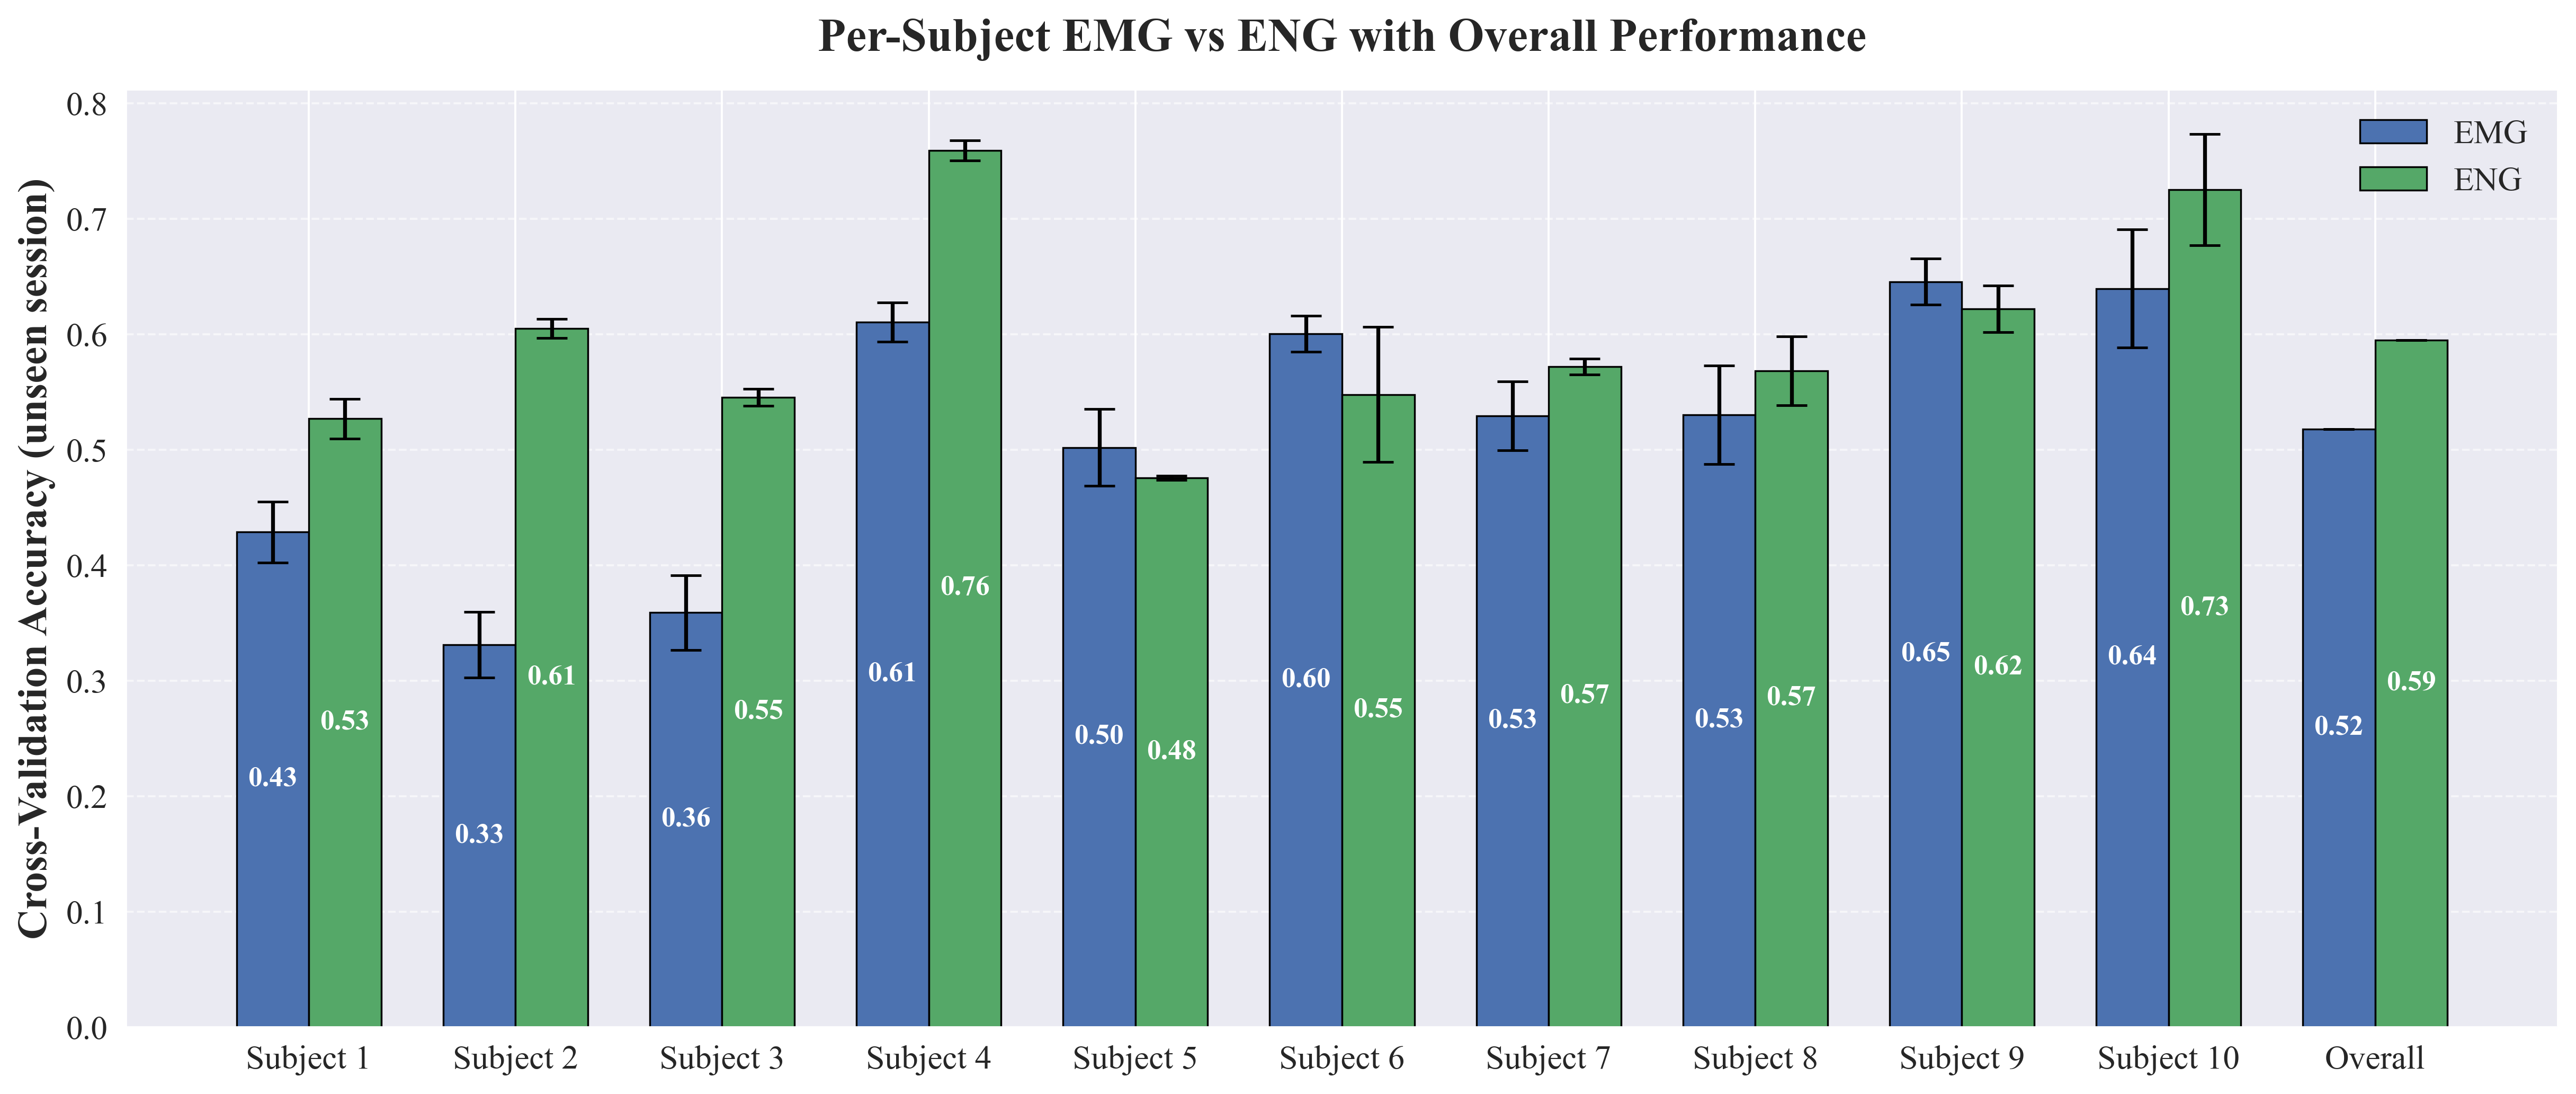

In [5]:
plt.rcParams['font.family'] = 'Times New Roman'
ENG_result_mean = [0.5268587470054626, 0.6050552427768707, 0.545380711555481, 0.7593218088150024, 0.4755933475494385, 0.5478944170475006, 0.5720518922805786, 0.5684217519760132, 0.6220743030309677, 0.7251902371163402]

EMG_result_mean = [0.42878782749176025, 0.3310706913471222, 0.35904206335544586, 0.6106011271476746, 0.5019441395998001, 0.6005978584289551,
                   0.5293917655944824, 0.5303820222616196, 0.6454729735851288, 0.639594031062847]

ENG_result_std = [0.01738905906677246, 0.008295983076095581, 0.007301270961761475, 0.008739054203033447, 0.001889646053314209, 0.05837675929069519,
                  0.006995737552642822, 0.029935557842254639, 0.02, 0.0481075885192015]

EMG_result_std = [0.026361674070358276, 0.028349608182907104, 0.032305046916007996, 0.01692497730255127, 0.033312246203422546, 0.01564866304397583,
                  0.02972644567489624, 0.04258860647678375, 0.02, 0.05109803514926083]

# Subjects
subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

# ---- Overall mean & std ----
EMG_overall_mean = np.mean(EMG_result_mean)
ENG_overall_mean = np.mean(ENG_result_mean)
EMG_overall_std = np.std(EMG_result_mean)
ENG_overall_std = np.std(ENG_result_mean)

# Append to list
subjects_with_overall = subjects + ["Overall"]
EMG_result_mean.append(EMG_overall_mean)
ENG_result_mean.append(ENG_overall_mean)
#EMG_result_std.append(EMG_overall_std)
#ENG_result_std.append(ENG_overall_std)
EMG_result_std.append(0)
ENG_result_std.append(0)


# ---- Barplot ----
x = np.arange(len(subjects_with_overall))  # subject index
width = 0.35

fig, ax = plt.subplots(figsize=(14,6), dpi=350)

bars1 = ax.bar(x - width/2, EMG_result_mean, width,
               yerr=EMG_result_std, capsize=6, label="EMG",
               color="#4C72B0", edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x + width/2, ENG_result_mean, width,
               yerr=ENG_result_std, capsize=6, label="ENG",
               color="#55A868", edgecolor="black", linewidth=0.7)

# Labels & Title
ax.set_ylabel("Cross-Validation Accuracy (unseen session)", fontsize=16, weight="bold")
ax.set_title("Per-Subject EMG vs ENG with Overall Performance", fontsize=18, weight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(subjects_with_overall, fontsize=13, rotation=0)
ax.tick_params(axis="y", labelsize=13)

# Grid for readability
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

# Legend
ax.legend(fontsize=13, frameon=False)

'''
# Annotate bars with values (shift higher to avoid overlap with error bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0,8), textcoords="offset points",   # ⬅︎ 여기 offset을 늘림
                    ha='center', va='bottom',
                    fontsize=11, weight="bold")
'''


# Annotate bars with values (inside bars)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height/2),  # 막대 중간쯤에 표시
                    ha='center', va='center',
                    fontsize=11, weight="bold", color="white")


plt.tight_layout()
plt.show()


In [25]:
len(EMG_result_mean), len(EMG_result_std),

(14, 14)

# t-SNE

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

import sys
sys.path.append('../../Share/')
sys.path.append('../../Share/Manual_processing/')
sys.path.append('../Exp6 - iENG vs sENG')
import baseline, config, Model, utils, Same_with_MATLAB, Feature_info, shared_iENG_sENG

import warnings
warnings.filterwarnings('ignore')

subjects = [f"Subject {i+1}" for i in range(len(["HM", "BY", "HJ", "JI", "YC", "HR", "CS", "MJ", "XY", "BR"]))]

base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/EMG_ENG/'

def get_data(subject, n_samples=500, random_state=42):
    X_train_EMG, y_train_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v1')
    X_test_EMG, y_test_EMG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='EMG', session='v2')

    X_train_ENG, y_train_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v1')
    X_test_ENG, y_test_ENG = shared_iENG_sENG.X_y_from_matfile(path = base_path+f'{subject}/', balance=True, modality='ENG', session='v2')

     # -------------------------------
    # Randomly select n_samples for train sets
    # -------------------------------
    rng = np.random.default_rng(random_state)

    if len(X_train_EMG) > n_samples:
        idx = rng.choice(len(X_train_EMG), n_samples, replace=False)
        X_train_EMG, y_train_EMG = X_train_EMG[idx], y_train_EMG[idx]

    if len(X_train_ENG) > n_samples:
        idx = rng.choice(len(X_train_ENG), n_samples, replace=False)
        X_train_ENG, y_train_ENG = X_train_ENG[idx], y_train_ENG[idx]


    print(X_train_EMG.shape, y_train_EMG.shape, X_test_EMG.shape, y_test_EMG.shape)
    #print(X_train_ENG.shape, y_train_ENG.shape, X_test_ENG.shape, y_test_ENG.shape)

    return X_train_EMG, X_train_ENG, y_train_EMG, y_train_ENG

In [ ]:
EMG_HM, ENG_HM, EMG_HM_y, ENG_HM_y = get_data(subject="Hunmin")
EMG_BY, ENG_BY, EMG_BY_y, ENG_BY_y = get_data(subject="Byeongchan")
EMG_HJ, ENG_HJ, EMG_HJ_y, ENG_HJ_y = get_data(subject="Hongjun")
EMG_JI, ENG_JI, EMG_JI_y, ENG_JI_y = get_data(subject="Jongin")
EMG_YC, ENG_YC, EMG_YC_y, ENG_YC_y = get_data(subject="Youngchul")
EMG_HR, ENG_HR, EMG_HR_y, ENG_HR_y = get_data(subject="Harold")
EMG_CS, ENG_CS, EMG_CS_y, ENG_CS_y = get_data(subject="Carlson")
EMG_MJ, ENG_MJ, EMG_MJ_y, ENG_MJ_y = get_data(subject="Minjeong")
EMG_XY, ENG_XY, EMG_XY_y, ENG_XY_y = get_data(subject="Xianyu")

y_EMG = np.concatenate([EMG_HM_y, EMG_BY_y, EMG_HJ_y, EMG_JI_y, EMG_YC_y, EMG_HR_y, EMG_CS_y, EMG_XY_y], axis=0)
y_ENG = np.concatenate([ENG_HM_y, ENG_BY_y, ENG_HJ_y, ENG_JI_y, ENG_YC_y, ENG_HR_y, ENG_CS_y, ENG_XY_y], axis=0)

X_EMG = np.concatenate([EMG_HM, EMG_BY, EMG_HJ, EMG_JI, EMG_YC, EMG_HR, EMG_CS, EMG_XY], axis=0)
X_ENG = np.concatenate([ENG_HM, ENG_BY, ENG_HJ, ENG_JI, ENG_YC, ENG_HR, ENG_CS, ENG_XY], axis=0)
X_EMG = X_EMG.reshape(X_EMG.shape[0], -1)
X_ENG = X_ENG.reshape(X_ENG.shape[0], -1)

labels_modality = np.array(['EMG'] * X_EMG.shape[0] + ['ENG'] * X_ENG.shape[0])

y_combined = np.concatenate([y_EMG, y_ENG], axis=0)
X_combined = np.concatenate([X_EMG, X_ENG], axis=0)
print(y_combined.shape, X_combined.shape)

tsne = TSNE(n_components=3, perplexity=50, learning_rate=800, max_iter=2000, random_state=42)
X_embedded = tsne.fit_transform(X_combined)

# 3D plot
fig = plt.figure(figsize=(15, 15), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'EMG': 'o', 'ENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['EMG', 'ENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid

#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
pd.DataFrame(X_embedded).to_csv('./t-sne_EMG_ENG.csv', index=False)
#X_embedded = pd.read_csv('./t-sne_EMG_ENG.csv')

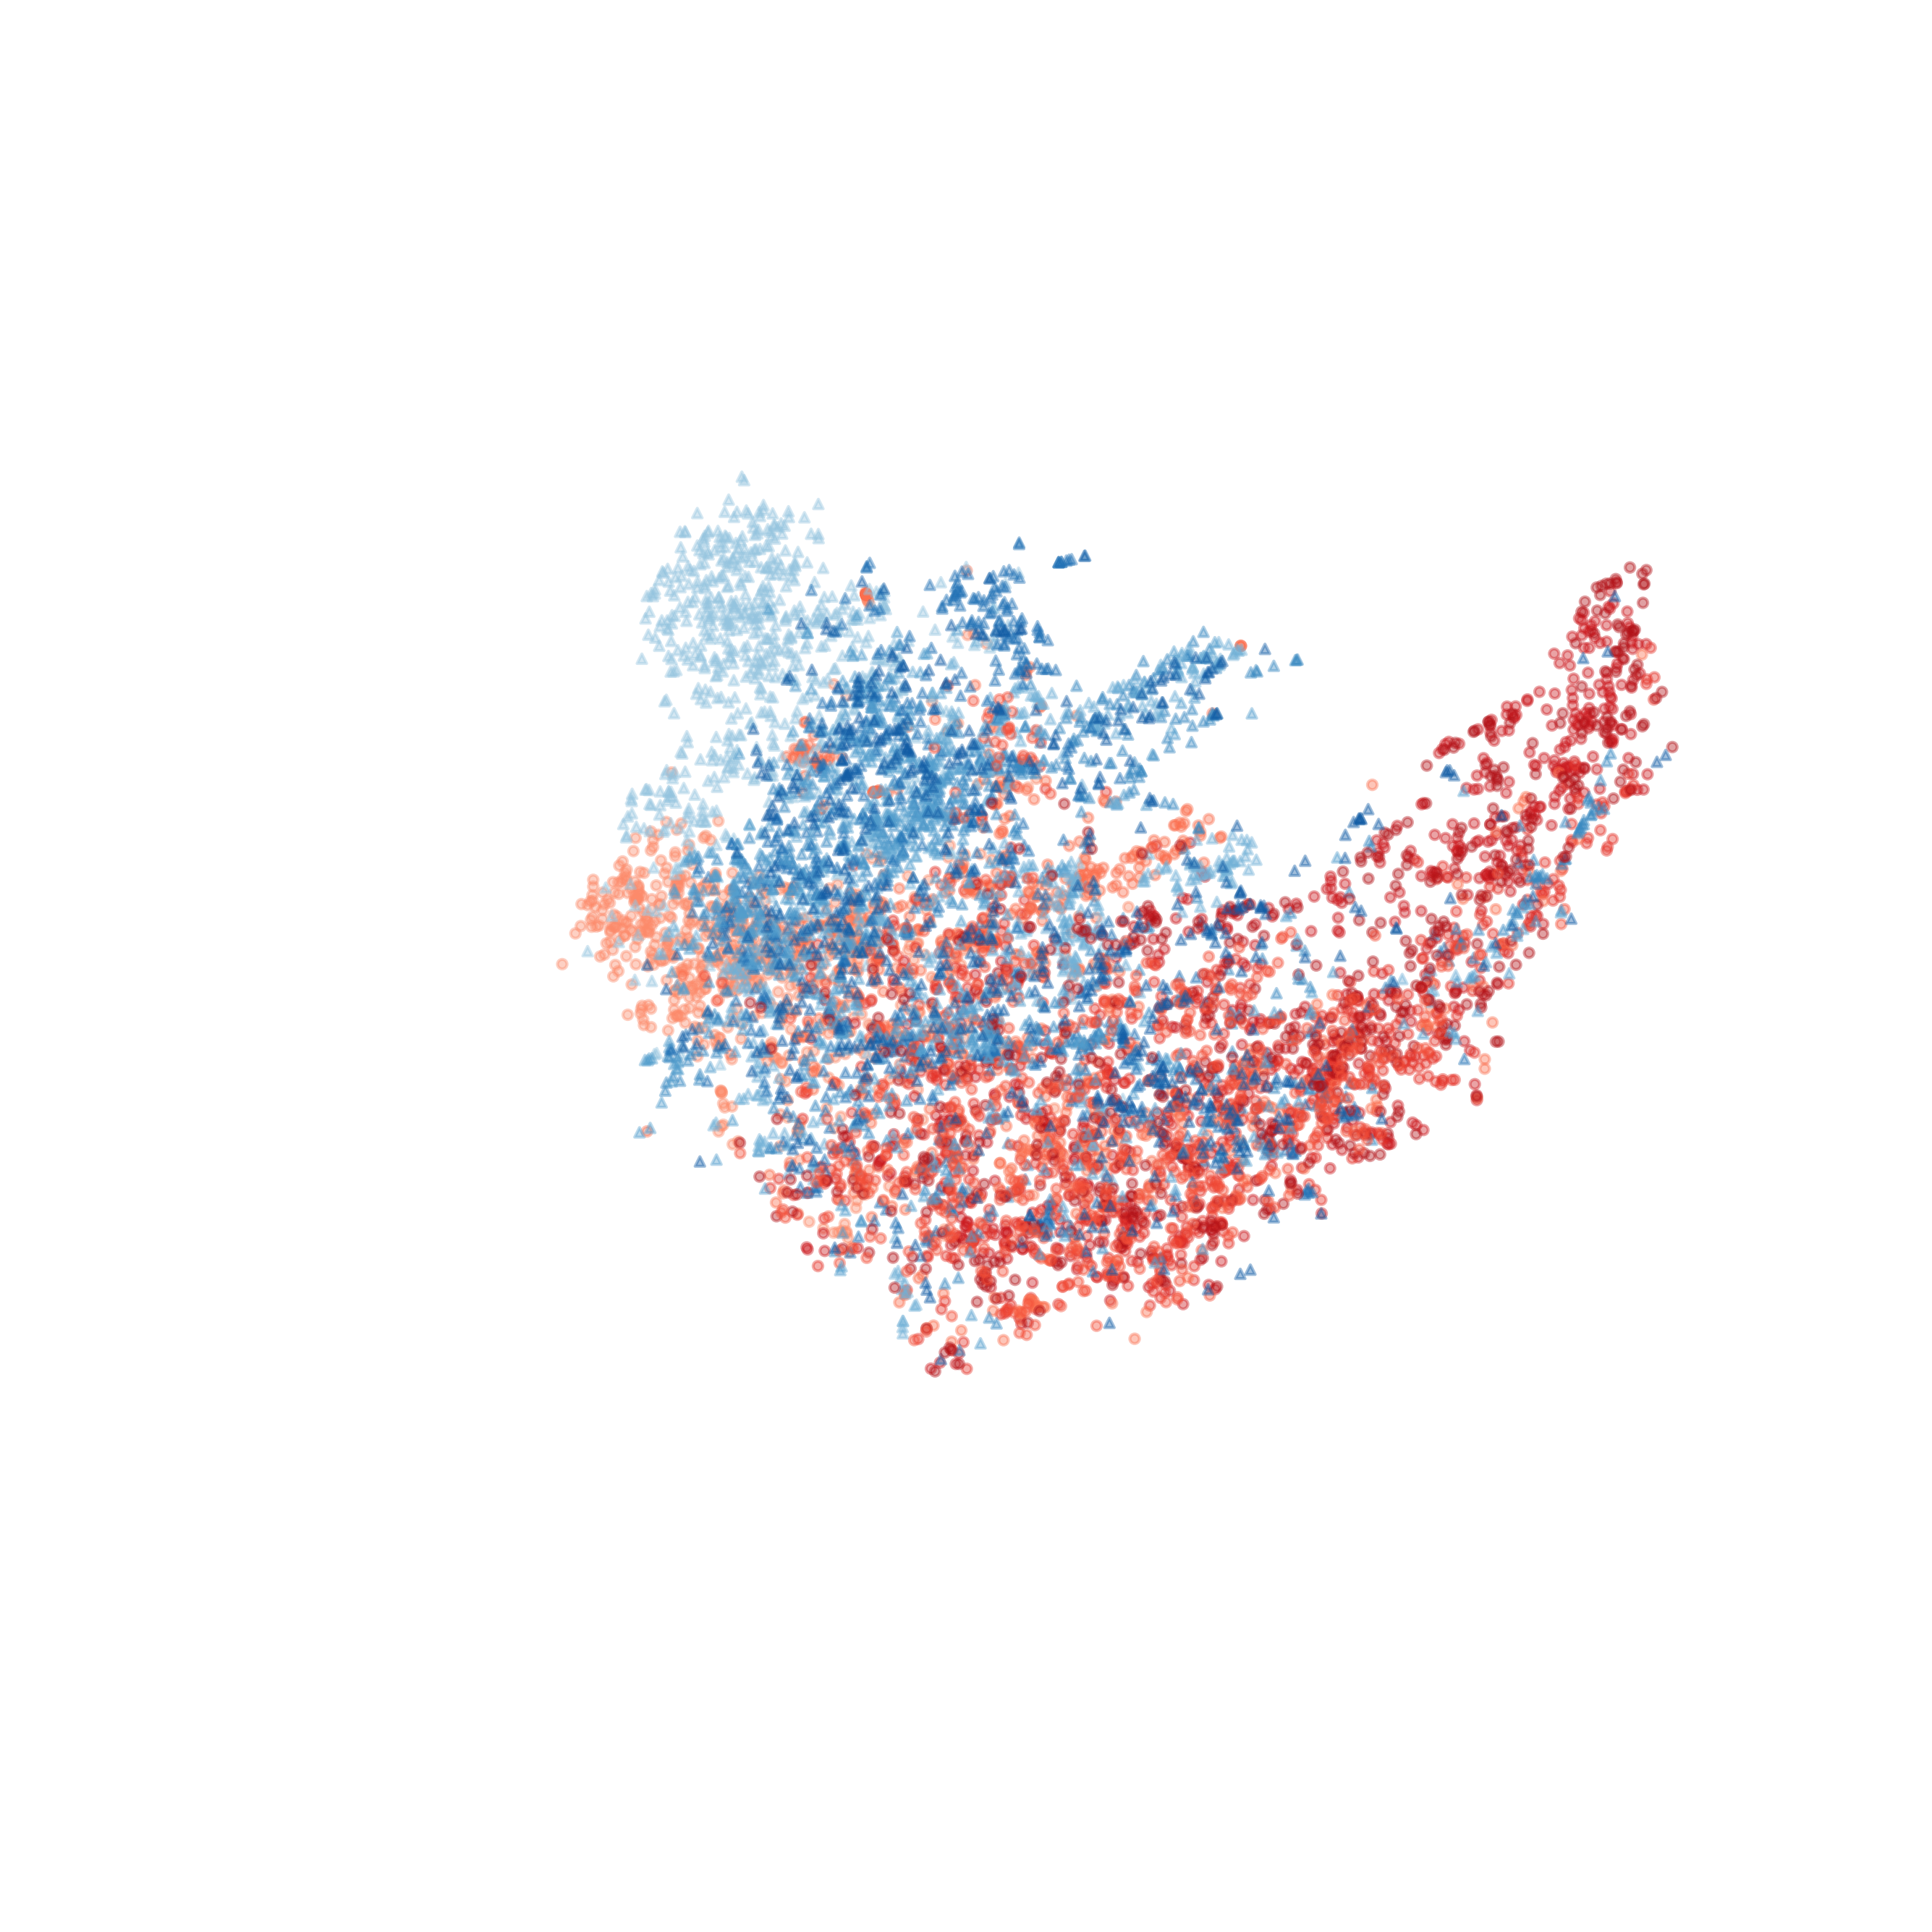

In [12]:
# 3D plot`
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'iENG': 'o', 'sENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['iENG', 'sENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

(500, 4, 14, 1) (500,) (1896, 4, 14, 1) (1896,)
(500, 4, 14, 1) (500,) (2760, 4, 14, 1) (2760,)
(500, 4, 14, 1) (500,) (2034, 4, 14, 1) (2034,)
(500, 4, 14, 1) (500,) (3384, 4, 14, 1) (3384,)
(500, 4, 14, 1) (500,) (2646, 4, 14, 1) (2646,)
(500, 4, 14, 1) (500,) (2166, 4, 14, 1) (2166,)
(500, 4, 14, 1) (500,) (2994, 4, 14, 1) (2994,)
(500, 4, 14, 1) (500,) (2130, 4, 14, 1) (2130,)
(500, 4, 14, 1) (500,) (2118, 4, 14, 1) (2118,)
(8000,) (8000, 56)


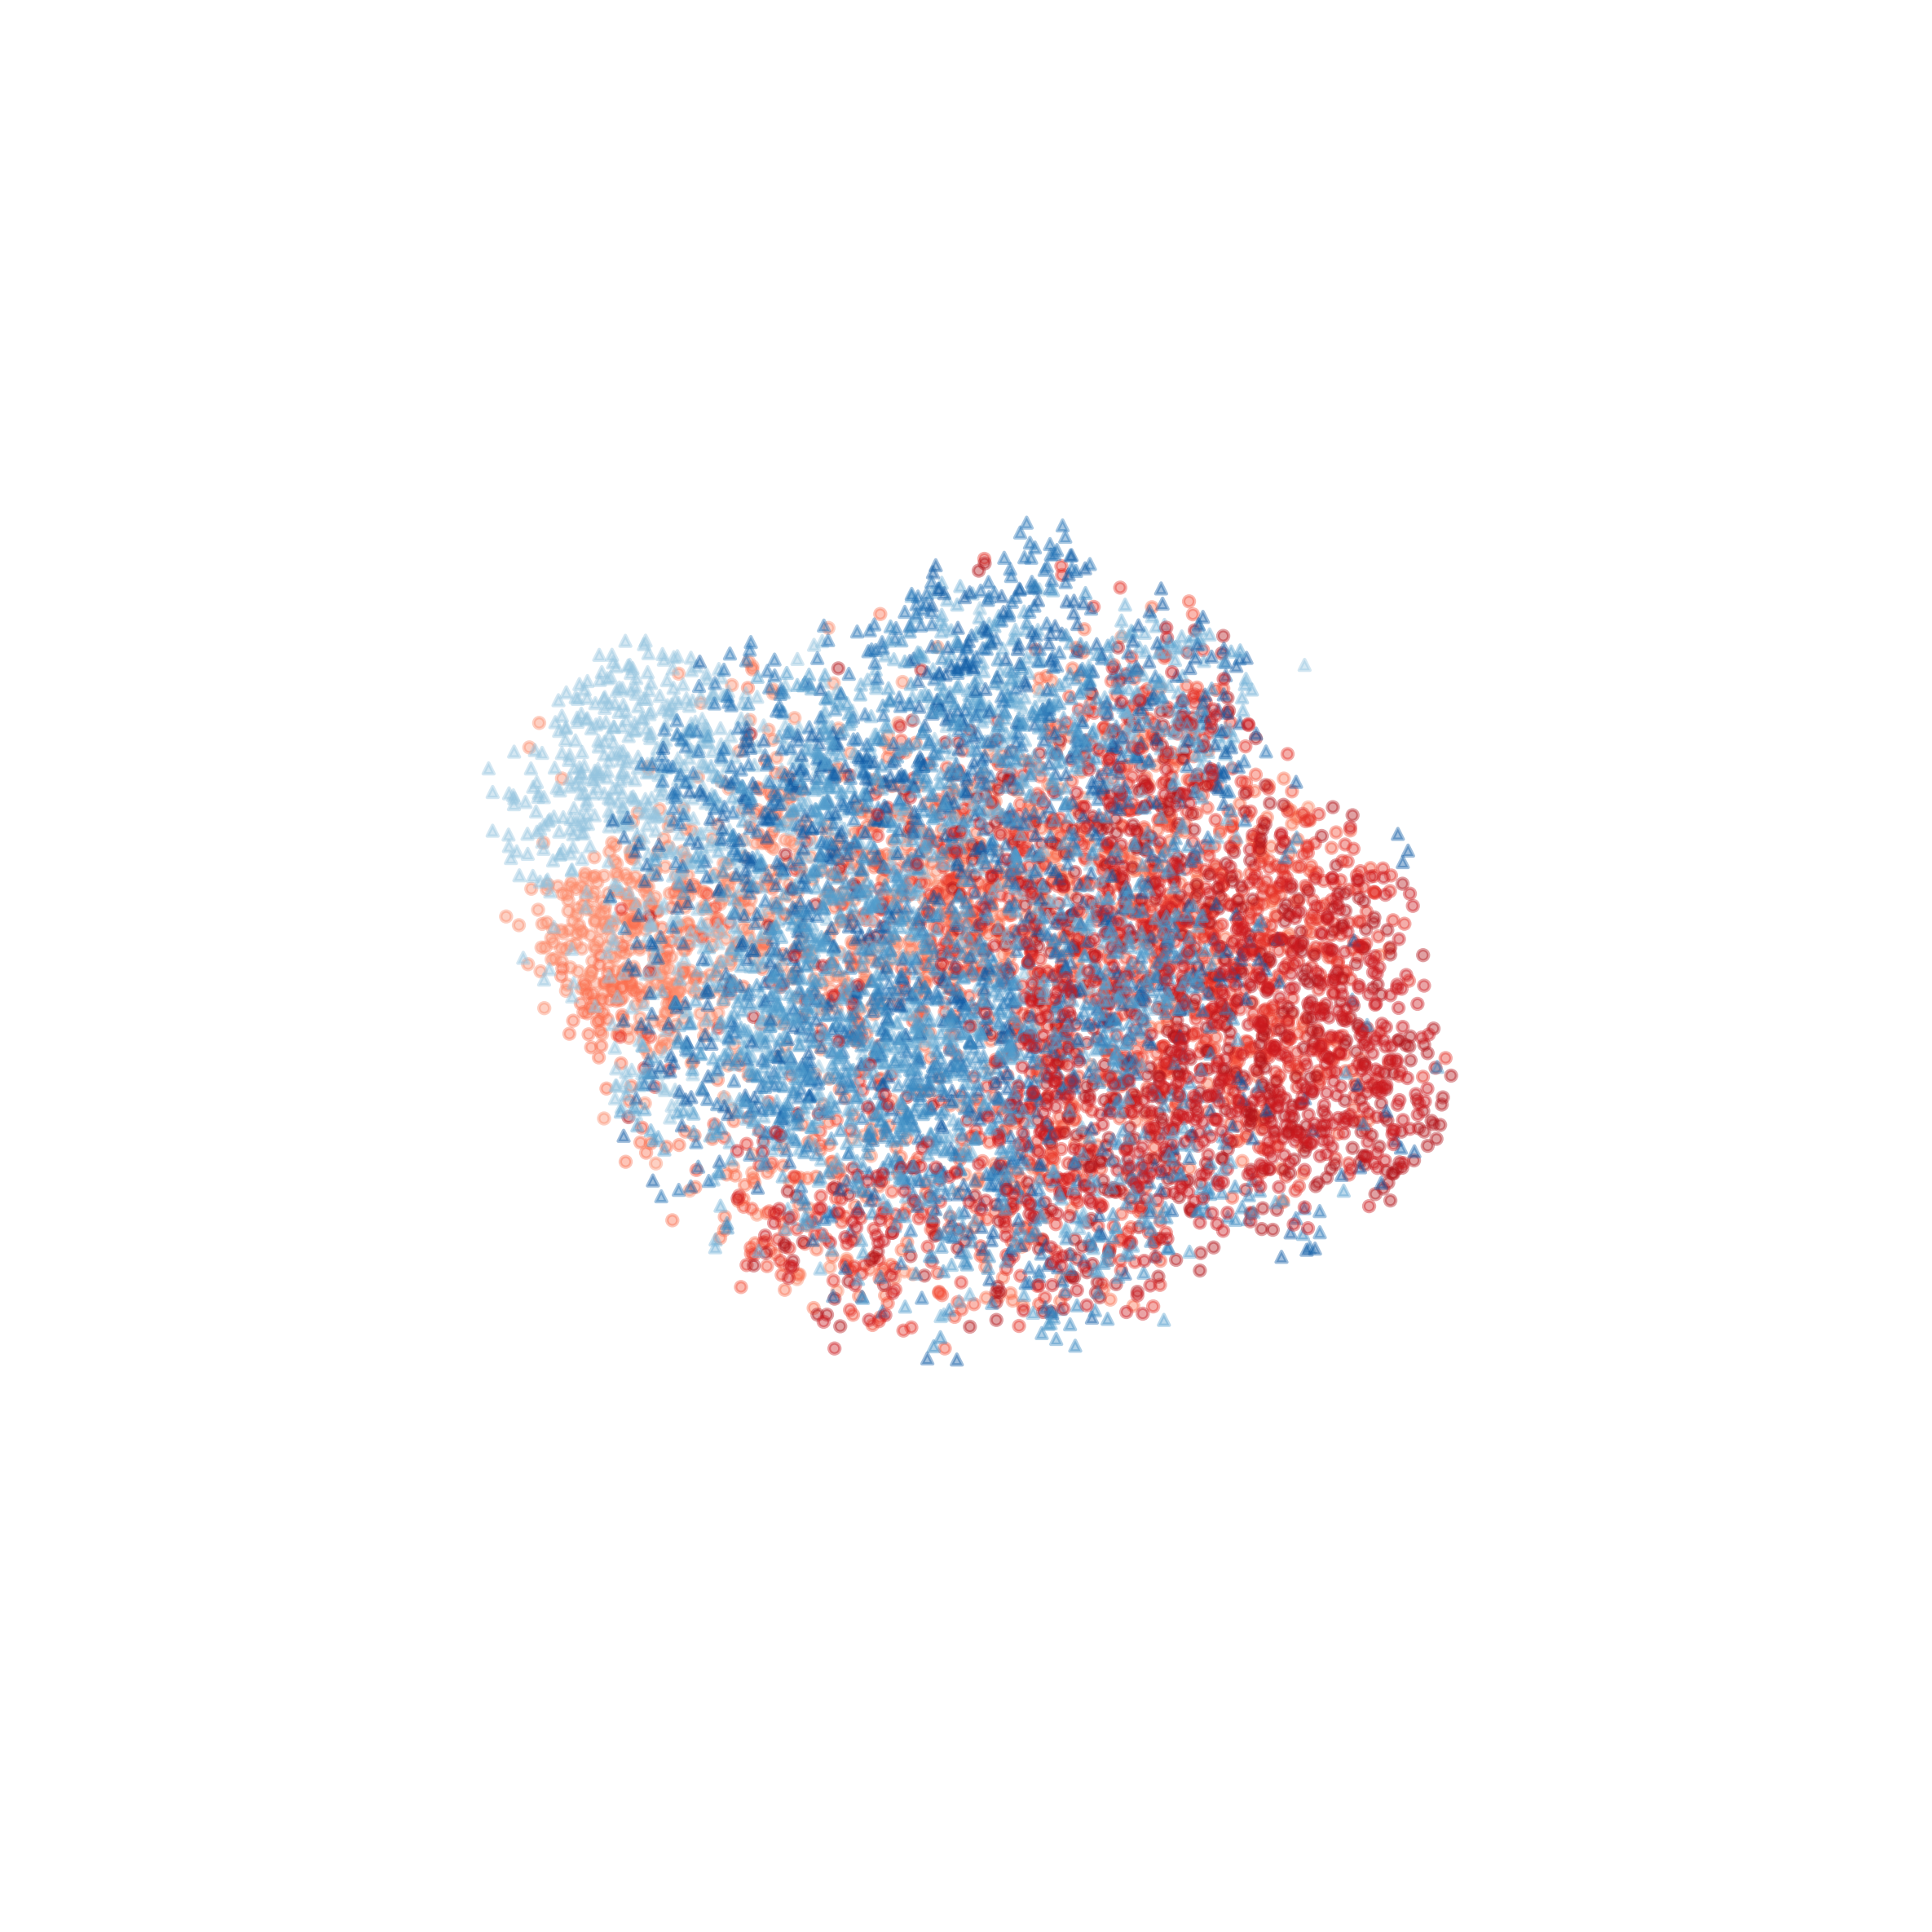

In [40]:
EMG_HM, ENG_HM, EMG_HM_y, ENG_HM_y = get_data(subject="Hunmin")
EMG_BY, ENG_BY, EMG_BY_y, ENG_BY_y = get_data(subject="Byeongchan")
EMG_HJ, ENG_HJ, EMG_HJ_y, ENG_HJ_y = get_data(subject="Hongjun")
EMG_JI, ENG_JI, EMG_JI_y, ENG_JI_y = get_data(subject="Jongin")
EMG_YC, ENG_YC, EMG_YC_y, ENG_YC_y = get_data(subject="Youngchul")
EMG_HR, ENG_HR, EMG_HR_y, ENG_HR_y = get_data(subject="Harold")
EMG_CS, ENG_CS, EMG_CS_y, ENG_CS_y = get_data(subject="Carlson")
EMG_MJ, ENG_MJ, EMG_MJ_y, ENG_MJ_y = get_data(subject="Minjeong")
EMG_XY, ENG_XY, EMG_XY_y, ENG_XY_y = get_data(subject="Xianyu")

y_EMG = np.concatenate([EMG_HM_y, EMG_BY_y, EMG_HJ_y, EMG_JI_y, EMG_YC_y, EMG_HR_y, EMG_CS_y, EMG_XY_y], axis=0)
y_ENG = np.concatenate([ENG_HM_y, ENG_BY_y, ENG_HJ_y, ENG_JI_y, ENG_YC_y, ENG_HR_y, ENG_CS_y, ENG_XY_y], axis=0)

X_EMG = np.concatenate([EMG_HM, EMG_BY, EMG_HJ, EMG_JI, EMG_YC, EMG_HR, EMG_CS, EMG_XY], axis=0)
X_ENG = np.concatenate([ENG_HM, ENG_BY, ENG_HJ, ENG_JI, ENG_YC, ENG_HR, ENG_CS, ENG_XY], axis=0)
X_EMG = X_EMG.reshape(X_EMG.shape[0], -1)
X_ENG = X_ENG.reshape(X_ENG.shape[0], -1)

labels_modality = np.array(['EMG'] * X_EMG.shape[0] + ['ENG'] * X_ENG.shape[0])

y_combined = np.concatenate([y_EMG, y_ENG], axis=0)
X_combined = np.concatenate([X_EMG, X_ENG], axis=0)

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_combined)  # X = your features

print(y_combined.shape, X_scaled.shape)

tsne = TSNE(
    n_components=3,
    perplexity=50,
    learning_rate=1000,
    max_iter=3000,
    random_state=42,
    #init='pca',        # PCA initialization often helps
    metric='euclidean'
)
X_embedded = tsne.fit_transform(X_scaled)

# 3D plot
fig = plt.figure(figsize=(8, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'EMG': 'o', 'ENG': '^'}

# Plot each modality with its color palette
for modality, palette in zip(['EMG', 'ENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=10, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid

#plt.title("3D t-SNE: iENG (Red) vs sENG (Blue)", fontsize=14)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

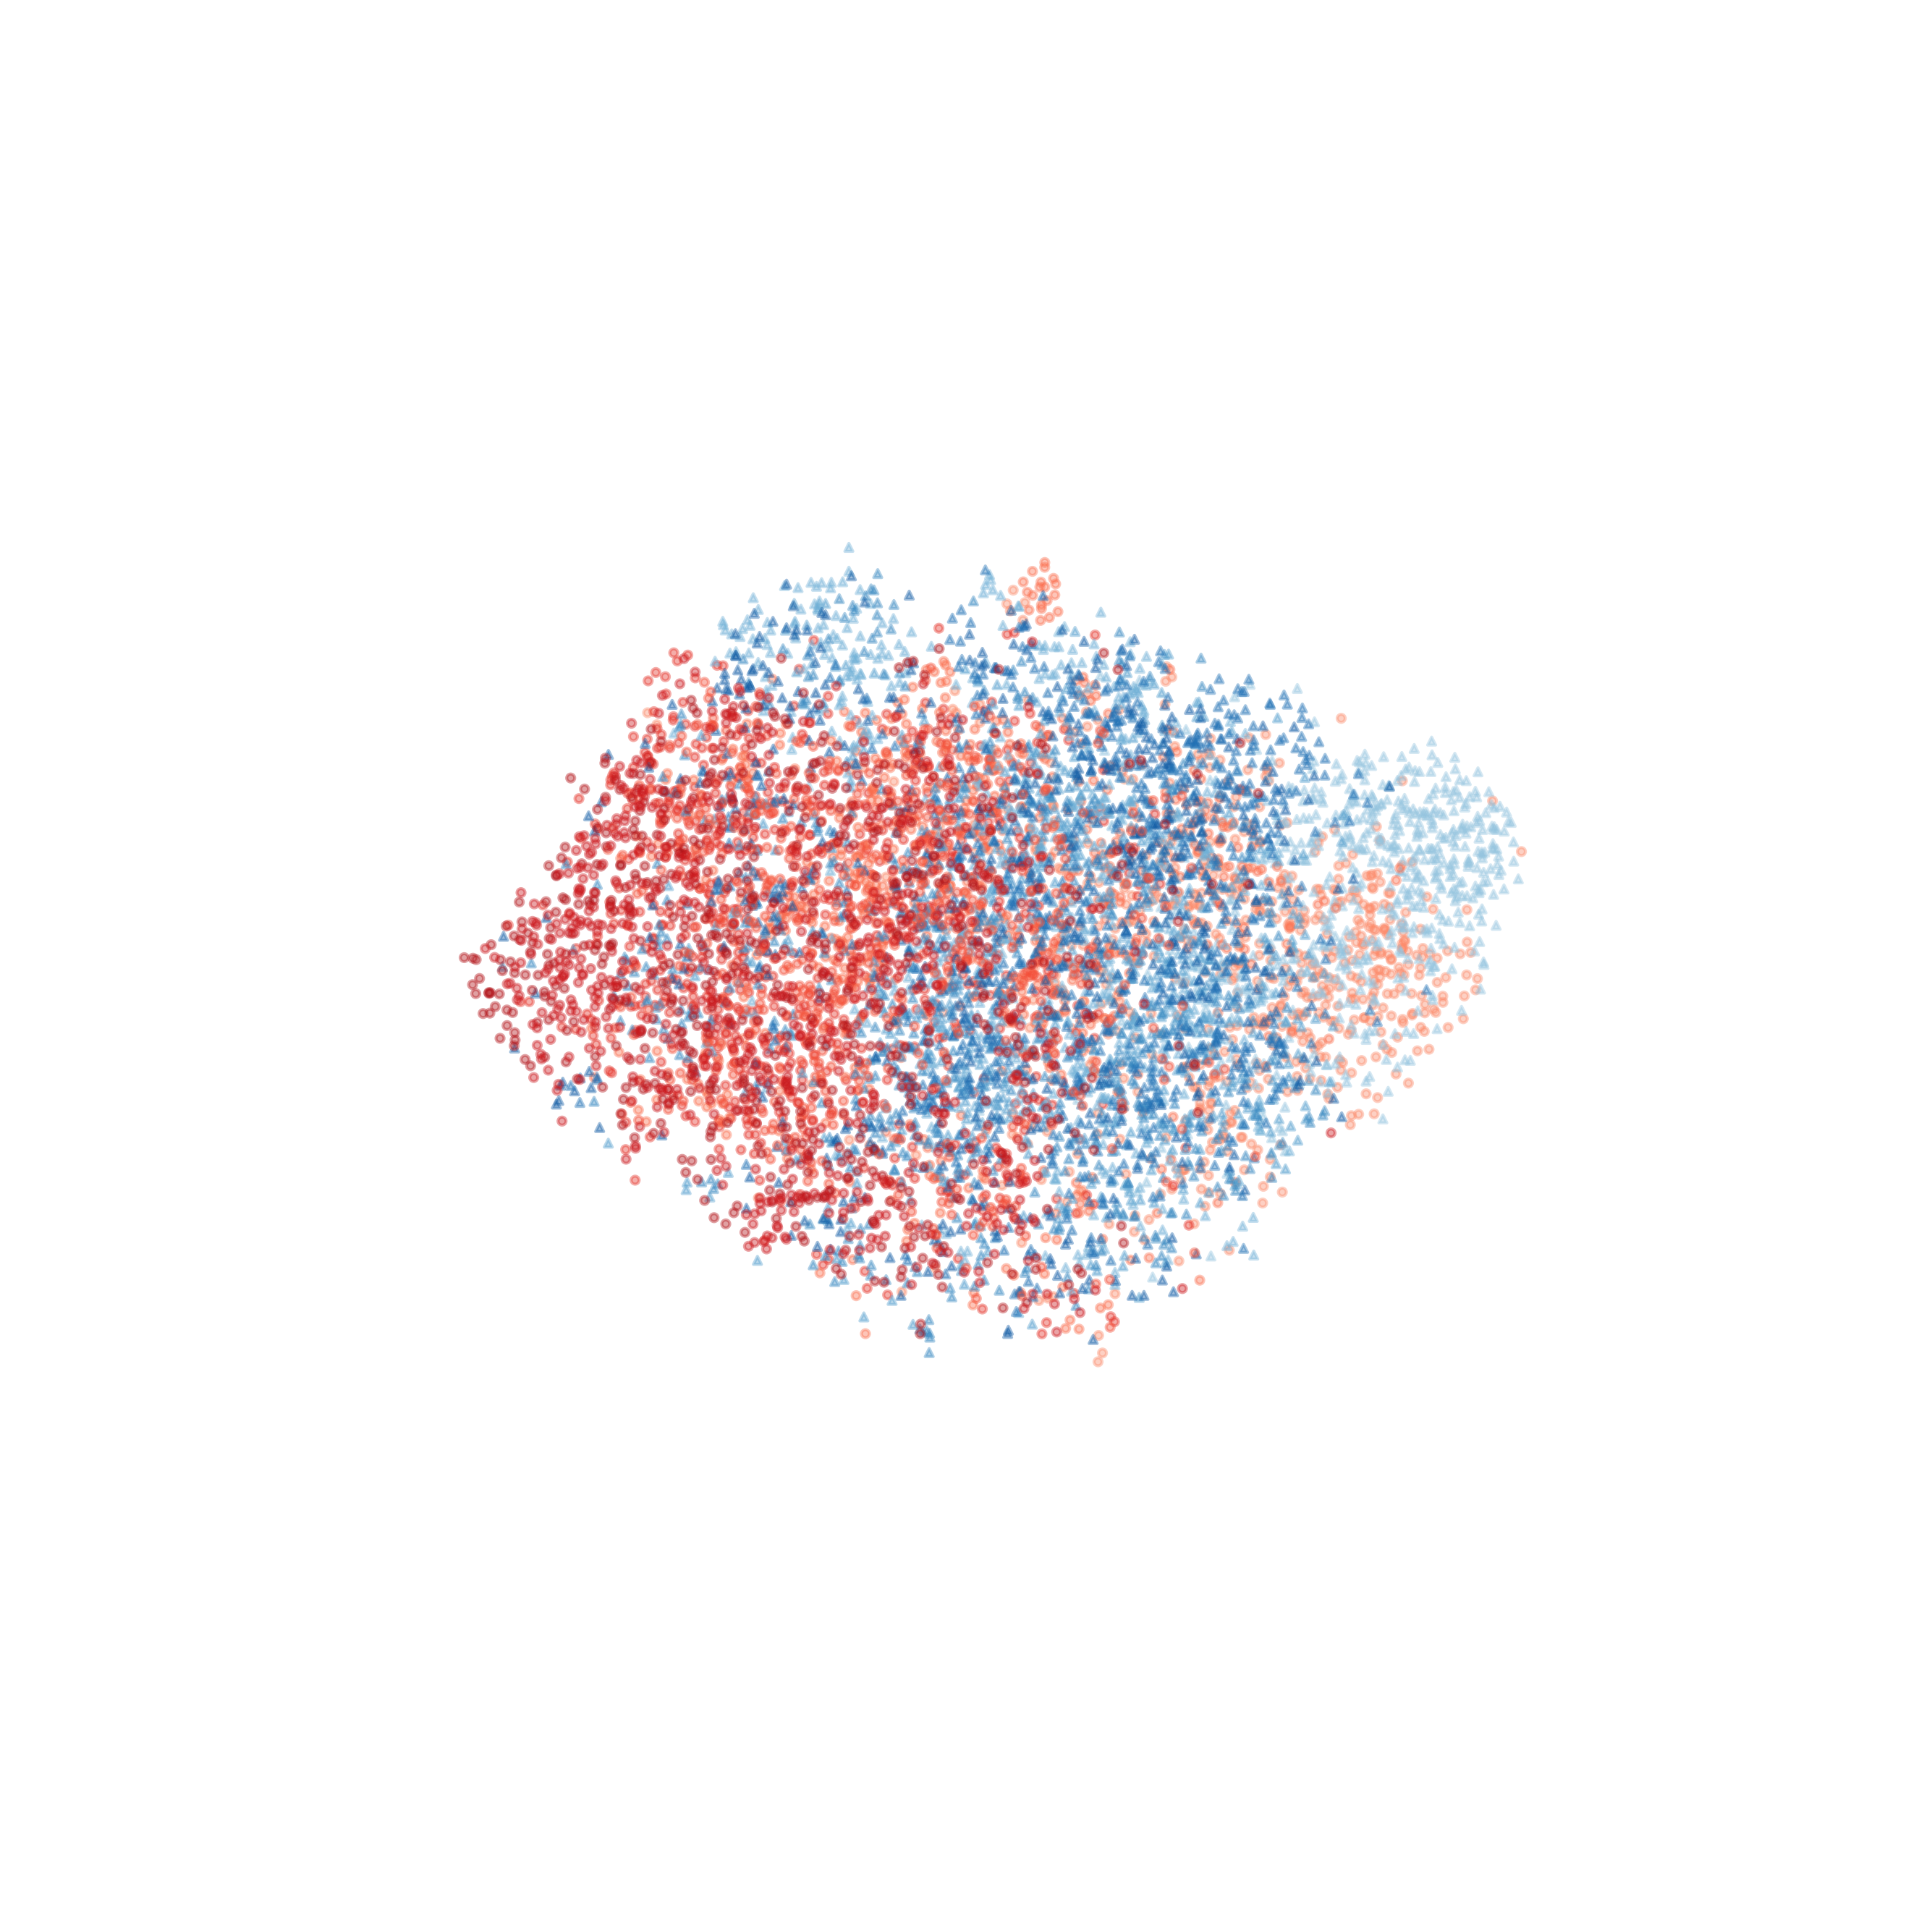

In [41]:
fig = plt.figure(figsize=(9, 9), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Define color palettes
reds = plt.cm.Reds(np.linspace(0.4, 1, 8))   # 6 shades of red (for iENG)
blues = plt.cm.Blues(np.linspace(0.4, 1, 8)) # 6 shades of blue (for sENG)

markers = {'EMG': 'o', 'ENG': '^'}
for modality, palette in zip(['EMG', 'ENG'], [reds, blues]):
    for cls in range(8):  # classes 0-5
        idx = (labels_modality == modality) & (y_combined == cls)
        ax.scatter(
            X_embedded[idx, 0], X_embedded[idx, 1], X_embedded[idx, 2],
            c=[palette[cls]], marker=markers[modality],
            s=7, alpha=0.4,
            label=f"{modality} - Class {cls}"
        )

ax.set_axis_off() # Remove all axes, ticks, labels, grid
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
#ax.view_init(elev=30, azim=30)  # 예시
#ax.view_init(elev=10, azim=0)    # 정면에서 낮게 바라봄
ax.view_init(elev=10, azim=90)    # 완전 위에서 내려다봄 (Top view)
#ax.view_init(elev=20, azim=120)  # 옆에서 비스듬히 봄
plt.tight_layout()
plt.show()